In [37]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Central Logging Function

In [38]:
# Determine working directory safely
if "__file__" in globals():
    repo_root = os.path.dirname(os.path.abspath(__file__))
else:
    repo_root = os.getcwd()

# Detect if we are already inside "Capstone Project"
current_folder = os.path.basename(repo_root)

if current_folder == "Capstone Project":
    base_dir = os.path.join(repo_root, "initial_data")
else:
    base_dir = os.path.join(repo_root, "Capstone Project", "initial_data")

print("Looking for data in:", base_dir)
print("Path exists:", os.path.exists(base_dir))

functions_data = {}

for i in range(1, 9):

    function_folder = os.path.join(base_dir, f"function_{i}")
    inputs_path = os.path.join(function_folder, "initial_inputs.npy")
    outputs_path = os.path.join(function_folder, "initial_outputs.npy")

    print(f"\nChecking f{i}:")
    print("  Inputs exist:", os.path.exists(inputs_path))
    print("  Outputs exist:", os.path.exists(outputs_path))

    if not os.path.exists(inputs_path) or not os.path.exists(outputs_path):
        print(f"Missing files for f{i}, skipping...")
        continue

    # Load arrays
    inputs = np.load(inputs_path)
    outputs = np.load(outputs_path)

    # Ensure 2D
    if inputs.ndim == 1:
        inputs = inputs.reshape(-1, 1)
    if outputs.ndim == 1:
        outputs = outputs.reshape(-1, 1)

    # Column names
    input_cols = [f"X{j+1}" for j in range(inputs.shape[1])]
    output_cols = [f"y{j+1}" for j in range(outputs.shape[1])]

    # Combine
    combined = np.concatenate([inputs, outputs], axis=1)
    df_combined = pd.DataFrame(combined, columns=input_cols + output_cols)

    # Store
    functions_data[f"f{i}"] = {
        "df": df_combined,
        "y_init": outputs.flatten().tolist(),
        "y_hist": []
    }

    print(f"Loaded f{i} | Shape: {df_combined.shape}")


Looking for data in: C:\Users\Hassa\OneDrive - Loughborough University\current\ML & AI\Capstone Project\initial_data
Path exists: True

Checking f1:
  Inputs exist: True
  Outputs exist: True
Loaded f1 | Shape: (10, 3)

Checking f2:
  Inputs exist: True
  Outputs exist: True
Loaded f2 | Shape: (10, 3)

Checking f3:
  Inputs exist: True
  Outputs exist: True
Loaded f3 | Shape: (15, 4)

Checking f4:
  Inputs exist: True
  Outputs exist: True
Loaded f4 | Shape: (30, 5)

Checking f5:
  Inputs exist: True
  Outputs exist: True
Loaded f5 | Shape: (20, 5)

Checking f6:
  Inputs exist: True
  Outputs exist: True
Loaded f6 | Shape: (20, 6)

Checking f7:
  Inputs exist: True
  Outputs exist: True
Loaded f7 | Shape: (30, 7)

Checking f8:
  Inputs exist: True
  Outputs exist: True
Loaded f8 | Shape: (40, 9)


In [39]:
# RECORD STORAGE
# This will log weekly progress
records = []

# FUNCTION TO LOG WEEKLY RESULTS
def log_week(week, method, function_name, y):
    """
    Logs a weekly submission and computes best observed value.
    """

    # Get function dictionary
    fd = functions_data[function_name]

    # Add new value to history
    fd["y_hist"].append(y)

    # Compute best value seen so far
    y_best = max(
        max(fd["y_init"]),  # best initial
        max(fd["y_hist"])   # best history
    )

    # Store record
    records.append({
        "Week": week,
        "Method": method,
        "Function": function_name,
        "y": y,
        "Best Observed": y_best
    })

### Load Week 0 Data

In [40]:
# COMPUTE WEEK 0 VALUES
# Week 0 = max initial output
week0 = {}

for f_name, fd in functions_data.items():
    week0[f_name] = max(fd["y_init"])

print("Week 0 Best Values:", week0)

Week 0 Best Values: {'f1': 7.710875114502849e-16, 'f2': 0.6112052157614438, 'f3': -0.034835313350078584, 'f4': -4.025542281908162, 'f5': 1088.8596181962705, 'f6': -0.7142649478202404, 'f7': 1.3649683044991994, 'f8': 9.598482002566342}


In [41]:
for f, y in week0.items():
    log_week(week=0, method="Initial Output", function_name=f, y=y)

### Week 1 

In [42]:
week1 = {
    "f1": 1.4034986520274933e-21,
    "f2": -0.07640833812988071,
    "f3": -0.04116779016532328,
    "f4": -1.8014266350928305,
    "f5": 684.5607486761136,
    "f6": -0.6872415681590064,
    "f7": 0.026543407526137847,
    "f8": 8.4452078666581,
}

for f, y in week1.items():
    log_week(week=1, method="Week 1", function_name=f, y=y)


### Week 2 

In [43]:
week2 = {
    "f1": 9.069108791316283e-223,
    "f2": -0.07975546223482953,
    "f3": -0.20496612752890705,
    "f4": -2.041748838194795,
    "f5": 2434.328593289806,
    "f6": -0.5648568336407203,
    "f7": 0.7653612109103147,
    "f8": 9.835131961,
}

for f, y in week2.items():
    log_week(week=2, method="Week 2", function_name=f, y=y)


### Week 3 

In [44]:
week3 = {
    "f1": 5.31459276351908e-15,
    "f2": 0.5037032225936308,
    "f3": -0.1117676821078815,
    "f4": 0.07045398603133579,
    "f5": 4171.124196806389,
    "f6": -0.7670334120297669,
    "f7": 0.4981320924641522,
    "f8": 9.948688972661,
}

for f, y in week3.items():
    log_week(week=3, method="Week 3", function_name=f, y=y)

### Week 4 

In [45]:
week4 = {
    "f1": 5.473776123300507e-57,
    "f2": 0.5661662506769448,
    "f3": -0.041279121306865105,
    "f4": -0.27637133038944084,
    "f5": 15.250051561683966,
    "f6": -1.421729209627387,
    "f7": 1.5985145628892428,
    "f8": 9.948688972661,
}

for f, y in week4.items():
    log_week(week=4, method="Week 4", function_name=f, y=y)

### Week 5 

In [46]:
week5 = {
    "f1": -1.0629331180647184e-161,
    "f2": 0.6824523528240423,
    "f3": -0.05314656740717209,
    "f4": -0.49820890718197175,
    "f5": 225.88673947929044,
    "f6": -0.7791148650103992,
    "f7": 0.32752252967109274,
    "f8": 9.861549762954,
}

for f, y in week5.items():
    log_week(week=5, method="Week 5", function_name=f, y=y)

### Week 6 

In [47]:
week6 = {
    "f1": 2.6078826238924974e-248,
    "f2": 0.3798198130144502,
    "f3": -0.03637482131814577,
    "f4": 0.34655132659709453,
    "f5": 849.8436606636637,
    "f6": -0.6814591029200937,
    "f7": 2.448290856114691,
    "f8": 5.5407934131584,
}

for f, y in week6.items():
    log_week(week=6, method="Week 6", function_name=f, y=y)

### Week 7 

In [48]:
week7 = {
    "f1": 2.2360328065267756e-98,
    "f2": 0.005940965665866974,
    "f3": -0.12413097550625916,
    "f4": -1.5762466920468117,
    "f5": 6575.295982756673,
    "f6": -1.8381389462062772,
    "f7": 1.3516399930526517,
    "f8": 7.5413772236639005,
}

for f, y in week7.items():
    log_week(week=7, method="Week 7", function_name=f, y=y)

### Week 8 

In [49]:
week8 = {
    "f1": 3.029971271826444e-187,
    "f2": -0.03174629008935288,
    "f3": -0.18116078744677863,
    "f4": -0.9393775297880427,
    "f5": 4660.244115920329,
    "f6": -2.7568441153569343,
    "f7": 0.13054782987236474,
    "f8": 8.7204756545406,
}

for f, y in week8.items():
    log_week(week=8, method="Week 8", function_name=f, y=y)

### Week 9

In [50]:
week9 = {
    "f1": 1.8670441080687443e-9,
    "f2": 0.5760952219798307,
    "f3": -0.13042760699767658,
    "f4": -4.6298356823203015,
    "f5": 6294.324532147924,
    "f6": -0.24936021594704408,
    "f7": 0.01764809003897648,
    "f8": 9.771881015877,
}

for f, y in week9.items():
    log_week(week=9, method="Week 9", function_name=f, y=y)

### Week 10

In [51]:
week10 = {
    "f1": 2.03320460262336e-8,
    "f2": 0.3296260629146929,
    "f3": -0.045607638959566356,
    "f4": 0.5545122853059294,
    "f5": 6971.761526528202,
    "f6": -0.2244249365413683,
    "f7": 2.55796551675835,
    "f8": 9.940025720132,
}

for f, y in week10.items():
    log_week(week=10, method="Week 10", function_name=f, y=y)

### Week 11

In [52]:
week11 = {
    "f1": 6.49621320377074e-7,
    "f2": 0.5741619847231454,
    "f3": -0.027528304452980934,
    "f4": -0.02563374723946721,
    "f5": 7735.182974570735,
    "f6": -0.7678682303650092,
    "f7": 2.5822487885107996,
    "f8": 9.943018117517,
}

for f, y in week11.items():
    log_week(week=11, method="Week 11", function_name=f, y=y)

### Week 12

In [53]:
week12 = {
    "f1": 0.000006604888098994687,
    "f2": 0.6373246839785176,
    "f3": -0.025630428429041174,
    "f4": -0.03859446180511794,
    "f5": 8219.09203524906,
    "f6": -0.2979553219711746,
    "f7": 2.521894443305605,
    "f8": 9.848852331891,
}

for f, y in week12.items():
    log_week(week=12, method="Week 12", function_name=f, y=y)

### Week 13

In [54]:
week13 = {
    "f1": -0.0012205886235109422,
    "f2": 0.5956321650793815,
    "f3": -0.05251903077949714,
    "f4": 0.3345514168224786,
    "f5": 8343.237138327517,
    "f6": -0.9491766567356656,
    "f7": 2.6948969486268437,
    "f8": 9.96583818412,
}

for f, y in week13.items():
    log_week(week=13, method="Week 13", function_name=f, y=y)

### Audit Table

In [55]:
df = pd.DataFrame(records)

# Step 3: Create function-specific DataFrames
df_f1 = df[df["Function"] == "f1"].reset_index(drop=True).drop(columns=["Function"])
df_f2 = df[df["Function"] == "f2"].reset_index(drop=True).drop(columns=["Function"])
df_f3 = df[df["Function"] == "f3"].reset_index(drop=True).drop(columns=["Function"])
df_f4 = df[df["Function"] == "f4"].reset_index(drop=True).drop(columns=["Function"])
df_f5 = df[df["Function"] == "f5"].reset_index(drop=True).drop(columns=["Function"])
df_f6 = df[df["Function"] == "f6"].reset_index(drop=True).drop(columns=["Function"])
df_f7 = df[df["Function"] == "f7"].reset_index(drop=True).drop(columns=["Function"])
df_f8 = df[df["Function"] == "f8"].reset_index(drop=True).drop(columns=["Function"])

# Preview one DataFrame
for i in range(1, 9):
    print(globals()[f"df_f{i}"])

    Week          Method              y  Best Observed
0      0  Initial Output   7.710875e-16   7.710875e-16
1      1          Week 1   1.403499e-21   7.710875e-16
2      2          Week 2  9.069109e-223   7.710875e-16
3      3          Week 3   5.314593e-15   5.314593e-15
4      4          Week 4   5.473776e-57   5.314593e-15
5      5          Week 5 -1.062933e-161   5.314593e-15
6      6          Week 6  2.607883e-248   5.314593e-15
7      7          Week 7   2.236033e-98   5.314593e-15
8      8          Week 8  3.029971e-187   5.314593e-15
9      9          Week 9   1.867044e-09   1.867044e-09
10    10         Week 10   2.033205e-08   2.033205e-08
11    11         Week 11   6.496213e-07   6.496213e-07
12    12         Week 12   6.604888e-06   6.604888e-06
13    13         Week 13  -1.220589e-03   6.604888e-06
    Week          Method         y  Best Observed
0      0  Initial Output  0.611205       0.611205
1      1          Week 1 -0.076408       0.611205
2      2          Week 2 

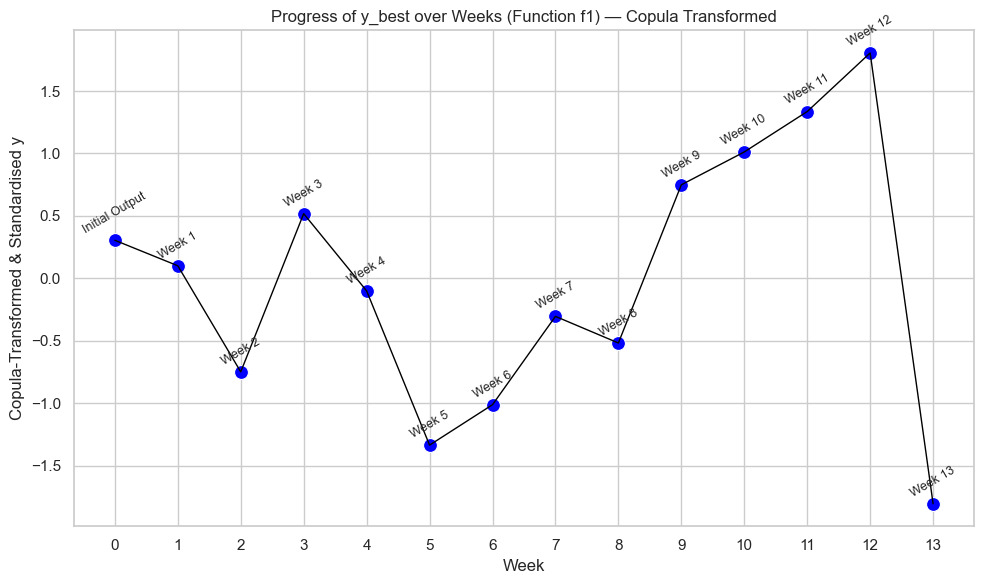

In [56]:
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler

# Transformation functions
def gaussian_copula_transform(y):
    n = len(y)
    ranks = np.argsort(np.argsort(y)) + 1
    quantiles = ranks / (n + 1)
    return norm.ppf(quantiles)

def standardise(y_copula):
    scaler = StandardScaler()
    y_scaled = scaler.fit_transform(y_copula.reshape(-1, 1)).ravel()
    return y_scaled, scaler


# Filter dataset
df_plot = df[df["Function"] == "f1"].reset_index(drop=True)

# Apply copula + standardisation
y = df_plot["y"].values

y_copula = gaussian_copula_transform(y)
y_copula_std, scaler = standardise(y_copula)

df_plot["y_copula_std"] = y_copula_std


# Plotting

sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))

ax = sns.scatterplot(
    data=df_plot,
    x="Week",
    y="y_copula_std",
    s=100,
    color="blue"
)

plt.plot(
    df_plot["Week"],
    df_plot["y_copula_std"],
    color="black",
    linewidth=1
)

# Annotate method above each point
for i, row in df_plot.iterrows():
    ax.text(
        x=row["Week"],
        y=row["y_copula_std"] + 0.01 * (df_plot["y_copula_std"].max() - df_plot["y_copula_std"].min()),
        s=row["Method"],
        ha="center",
        va="bottom",
        fontsize=9,
        rotation=30
    )

plt.xlabel("Week")
plt.ylabel("Copula-Transformed & Standardised y")
plt.title("Progress of y_best over Weeks (Function f1) — Copula Transformed")
plt.xticks(range(df_plot["Week"].min(), df_plot["Week"].max() + 1))
plt.tight_layout()
plt.show()


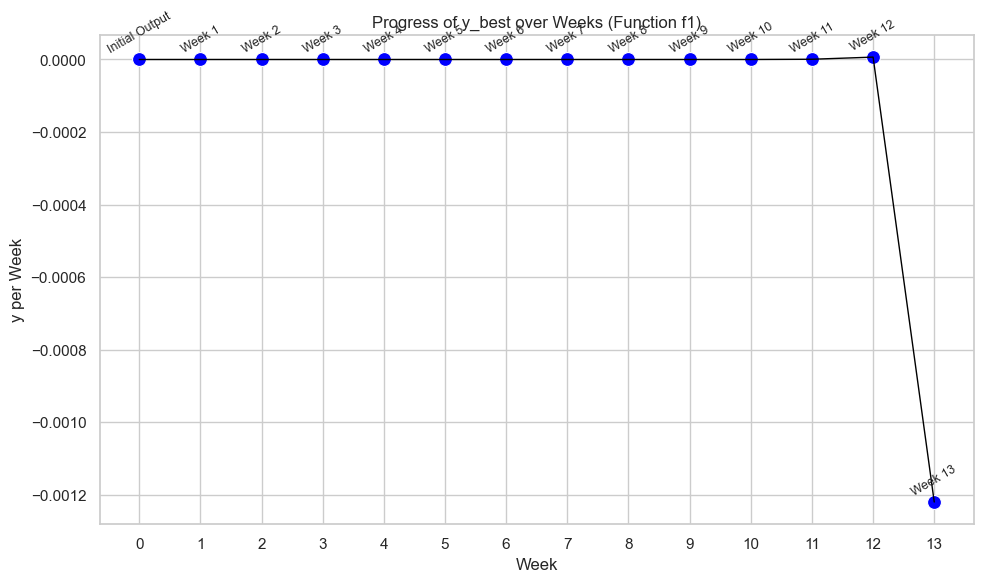

In [57]:
df_plot = df[df["Function"] == "f1"].reset_index(drop=True)

# Set style
sns.set(style="whitegrid")

# Create the plot
plt.figure(figsize=(10, 6))

ax = sns.scatterplot(
    data=df_plot,
    x="Week",
    y="y",
    s=100,               # size of dots
    color="blue"
)

plt.plot(
    df_plot["Week"], 
    df_plot["y"], 
    color="black",      # black line
    linewidth=1         # thin line
)

# Annotate method above each point
for i, row in df_plot.iterrows():
    ax.text(
        x=row["Week"],
        y=row["y"] + 0.01 * (df_plot["y"].max() - df_plot["y"].min()),  # slight vertical offset
        s=row["Method"],
        ha="center",
        va="bottom",
        fontsize=9,
        rotation=30
    )

# Labels and title
plt.xlabel("Week")
plt.ylabel("y per Week")
plt.title("Progress of y_best over Weeks (Function f1)")
plt.xticks(range(df_plot["Week"].min(), df_plot["Week"].max() + 1))  # 1 interval on X axis
plt.tight_layout()
plt.show()

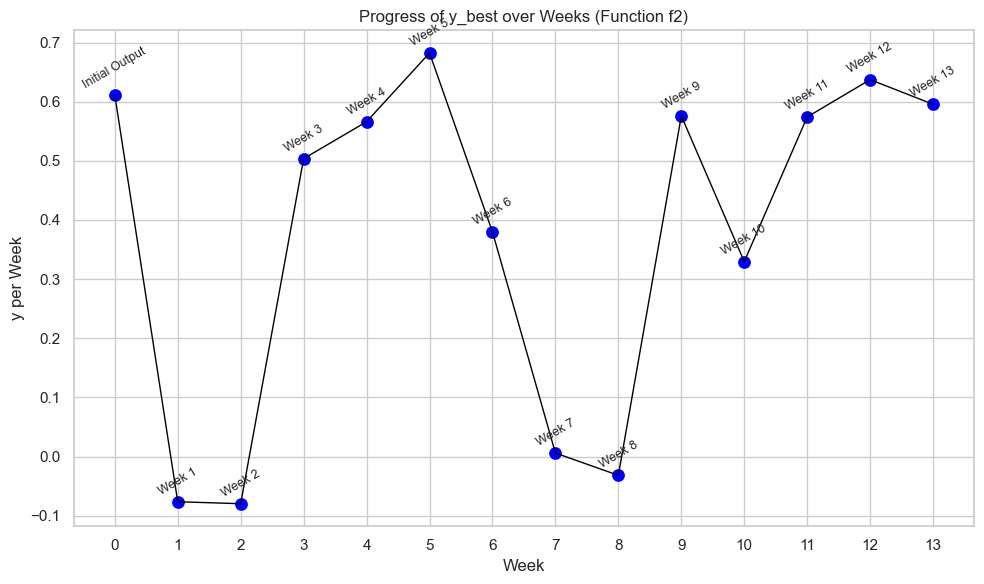

In [58]:
df_plot = df[df["Function"] == "f2"].reset_index(drop=True)

# Set style
sns.set(style="whitegrid")

# Create the plot
plt.figure(figsize=(10, 6))

ax = sns.scatterplot(
    data=df_plot,
    x="Week",
    y="y",
    s=100,               # size of dots
    color="blue"
)

plt.plot(
    df_plot["Week"], 
    df_plot["y"], 
    color="black",      # black line
    linewidth=1         # thin line
)

# Annotate method above each point
for i, row in df_plot.iterrows():
    ax.text(
        x=row["Week"],
        y=row["y"] + 0.01 * (df_plot["y"].max() - df_plot["y"].min()),  # slight vertical offset
        s=row["Method"],
        ha="center",
        va="bottom",
        fontsize=9,
        rotation=30
    )

# Labels and title
plt.xlabel("Week")
plt.ylabel("y per Week")
plt.title("Progress of y_best over Weeks (Function f2)")
plt.xticks(range(df_plot["Week"].min(), df_plot["Week"].max() + 1))  # 1 interval on X axis
plt.tight_layout()
plt.show()

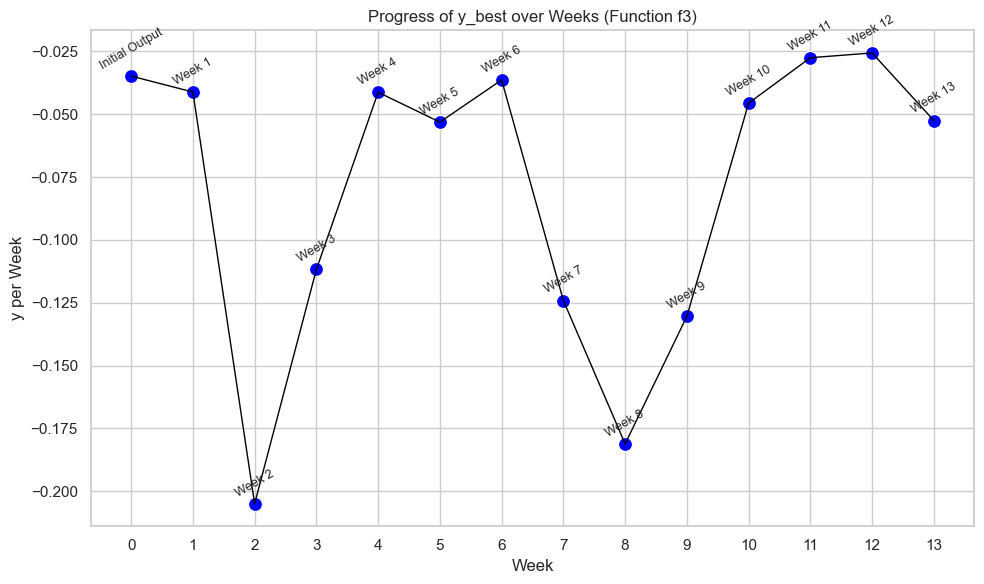

In [59]:
df_plot = df[df["Function"] == "f3"].reset_index(drop=True)

# Set style
sns.set(style="whitegrid")

# Create the plot
plt.figure(figsize=(10, 6))

ax = sns.scatterplot(
    data=df_plot,
    x="Week",
    y="y",
    s=100,               # size of dots
    color="blue"
)

plt.plot(
    df_plot["Week"], 
    df_plot["y"], 
    color="black",      # black line
    linewidth=1         # thin line
)

# Annotate method above each point
for i, row in df_plot.iterrows():
    ax.text(
        x=row["Week"],
        y=row["y"] + 0.01 * (df_plot["y"].max() - df_plot["y"].min()),  # slight vertical offset
        s=row["Method"],
        ha="center",
        va="bottom",
        fontsize=9,
        rotation=30
    )

# Labels and title
plt.xlabel("Week")
plt.ylabel("y per Week")
plt.title("Progress of y_best over Weeks (Function f3)")
plt.xticks(range(df_plot["Week"].min(), df_plot["Week"].max() + 1))  # 1 interval on X axis
plt.tight_layout()
plt.show()

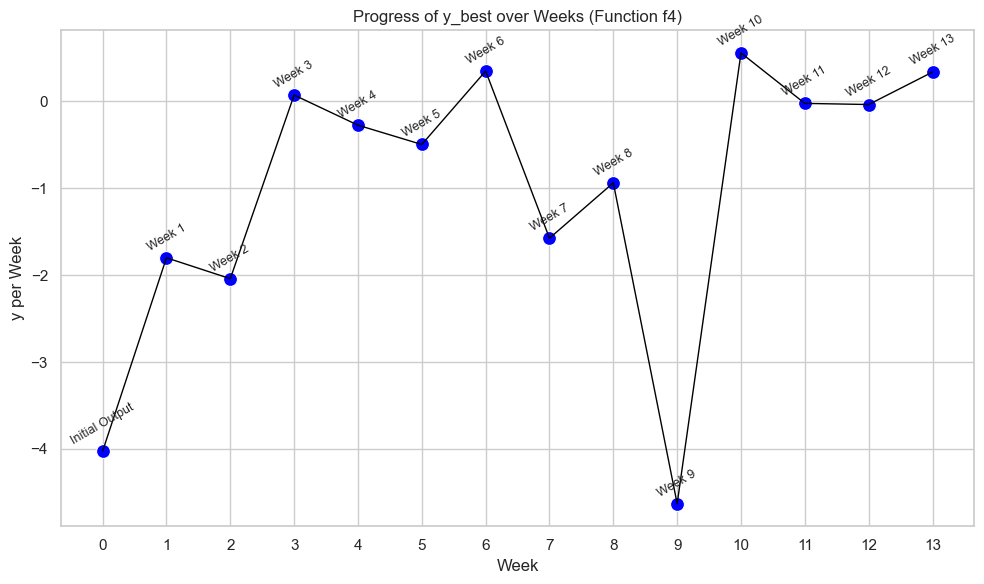

In [60]:
df_plot = df[df["Function"] == "f4"].reset_index(drop=True)

# Set style
sns.set(style="whitegrid")

# Create the plot
plt.figure(figsize=(10, 6))

ax = sns.scatterplot(
    data=df_plot,
    x="Week",
    y="y",
    s=100,               # size of dots
    color="blue"
)

plt.plot(
    df_plot["Week"], 
    df_plot["y"], 
    color="black",      # black line
    linewidth=1         # thin line
)

# Annotate method above each point
for i, row in df_plot.iterrows():
    ax.text(
        x=row["Week"],
        y=row["y"] + 0.01 * (df_plot["y"].max() - df_plot["y"].min()),  # slight vertical offset
        s=row["Method"],
        ha="center",
        va="bottom",
        fontsize=9,
        rotation=30
    )

# Labels and title
plt.xlabel("Week")
plt.ylabel("y per Week")
plt.title("Progress of y_best over Weeks (Function f4)")
plt.xticks(range(df_plot["Week"].min(), df_plot["Week"].max() + 1))  # 1 interval on X axis
plt.tight_layout()
plt.show()

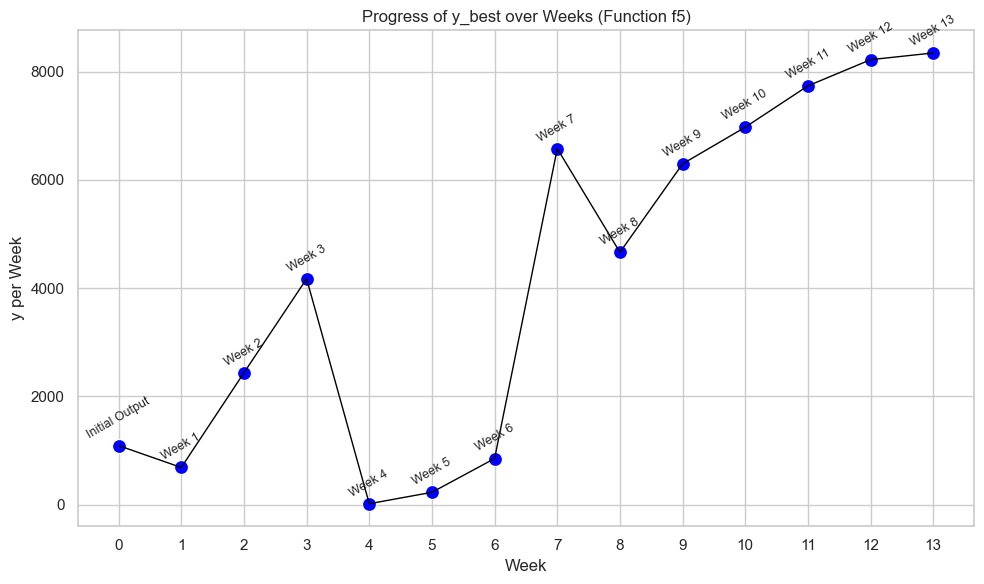

In [61]:
df_plot = df[df["Function"] == "f5"].reset_index(drop=True)

# Set style
sns.set(style="whitegrid")

# Create the plot
plt.figure(figsize=(10, 6))

ax = sns.scatterplot(
    data=df_plot,
    x="Week",
    y="y",
    s=100,               # size of dots
    color="blue"
)

plt.plot(
    df_plot["Week"], 
    df_plot["y"], 
    color="black",      # black line
    linewidth=1         # thin line
)

# Annotate method above each point
for i, row in df_plot.iterrows():
    ax.text(
        x=row["Week"],
        y=row["y"] + 0.01 * (df_plot["y"].max() - df_plot["y"].min()),  # slight vertical offset
        s=row["Method"],
        ha="center",
        va="bottom",
        fontsize=9,
        rotation=30
    )

# Labels and title
plt.xlabel("Week")
plt.ylabel("y per Week")
plt.title("Progress of y_best over Weeks (Function f5)")
plt.xticks(range(df_plot["Week"].min(), df_plot["Week"].max() + 1))  # 1 interval on X axis
plt.tight_layout()
plt.show()

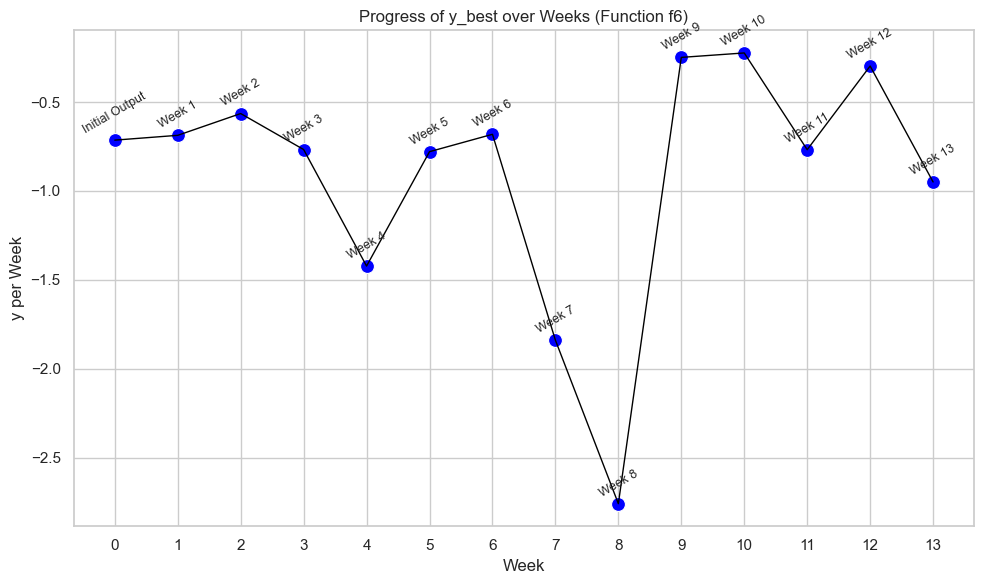

In [62]:
df_plot = df[df["Function"] == "f6"].reset_index(drop=True)

# Set style
sns.set(style="whitegrid")

# Create the plot
plt.figure(figsize=(10, 6))

ax = sns.scatterplot(
    data=df_plot,
    x="Week",
    y="y",
    s=100,               # size of dots
    color="blue"
)

plt.plot(
    df_plot["Week"], 
    df_plot["y"], 
    color="black",      # black line
    linewidth=1         # thin line
)

# Annotate method above each point
for i, row in df_plot.iterrows():
    ax.text(
        x=row["Week"],
        y=row["y"] + 0.01 * (df_plot["y"].max() - df_plot["y"].min()),  # slight vertical offset
        s=row["Method"],
        ha="center",
        va="bottom",
        fontsize=9,
        rotation=30
    )

# Labels and title
plt.xlabel("Week")
plt.ylabel("y per Week")
plt.title("Progress of y_best over Weeks (Function f6)")
plt.xticks(range(df_plot["Week"].min(), df_plot["Week"].max() + 1))  # 1 interval on X axis
plt.tight_layout()
plt.show()

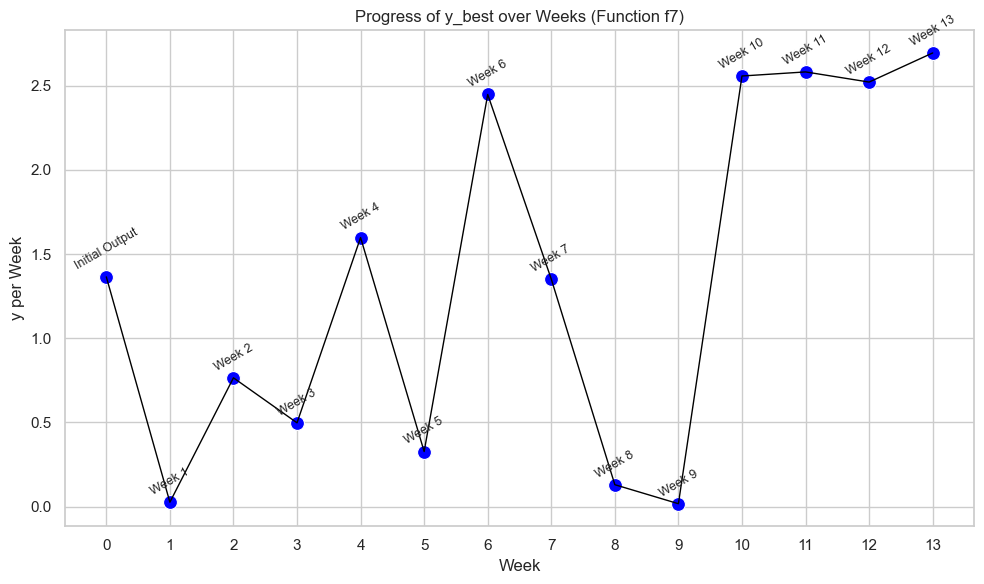

In [63]:
df_plot = df[df["Function"] == "f7"].reset_index(drop=True)

# Set style
sns.set(style="whitegrid")

# Create the plot
plt.figure(figsize=(10, 6))

ax = sns.scatterplot(
    data=df_plot,
    x="Week",
    y="y",
    s=100,               # size of dots
    color="blue"
)

plt.plot(
    df_plot["Week"], 
    df_plot["y"], 
    color="black",      # black line
    linewidth=1         # thin line
)

# Annotate method above each point
for i, row in df_plot.iterrows():
    ax.text(
        x=row["Week"],
        y=row["y"] + 0.01 * (df_plot["y"].max() - df_plot["y"].min()),  # slight vertical offset
        s=row["Method"],
        ha="center",
        va="bottom",
        fontsize=9,
        rotation=30
    )

# Labels and title
plt.xlabel("Week")
plt.ylabel("y per Week")
plt.title("Progress of y_best over Weeks (Function f7)")
plt.xticks(range(df_plot["Week"].min(), df_plot["Week"].max() + 1))  # 1 interval on X axis
plt.tight_layout()
plt.show()

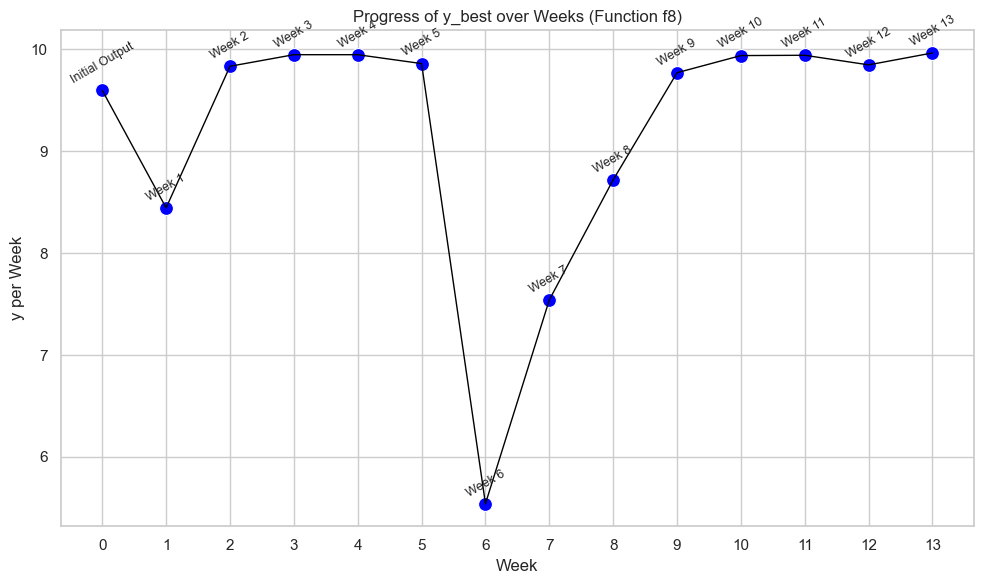

In [64]:
df_plot = df[df["Function"] == "f8"].reset_index(drop=True)

# Set style
sns.set(style="whitegrid")

# Create the plot
plt.figure(figsize=(10, 6))

ax = sns.scatterplot(
    data=df_plot,
    x="Week",
    y="y",
    s=100,               # size of dots
    color="blue"
)

plt.plot(
    df_plot["Week"], 
    df_plot["y"], 
    color="black",      # black line
    linewidth=1         # thin line
)

# Annotate method above each point
for i, row in df_plot.iterrows():
    ax.text(
        x=row["Week"],
        y=row["y"] + 0.01 * (df_plot["y"].max() - df_plot["y"].min()),  # slight vertical offset
        s=row["Method"],
        ha="center",
        va="bottom",
        fontsize=9,
        rotation=30
    )

# Labels and title
plt.xlabel("Week")
plt.ylabel("y per Week")
plt.title("Progress of y_best over Weeks (Function f8)")
plt.xticks(range(df_plot["Week"].min(), df_plot["Week"].max() + 1))  # 1 interval on X axis
plt.tight_layout()
plt.show()